# **Kasus 3: Fase Paramagnetik (T = 4.0)**

## **Tujuan**

Mensimulasikan Model Ising 2 Dimensi menggunakan algoritma Metropolis pada suhu tinggi (T = 4.0) untuk mengamati perilaku sistem ketika energi termal mendominasi interaksi antar-spin sehingga magnetisasi rata-rata mendekati nol..

## **Parameter Simulasi**

- Ukuran kisi : 20 × 20
- Suhu : 4.0
- Monte Carlo Steps : 200000
- Inisialisasi : Hot Start (acak)

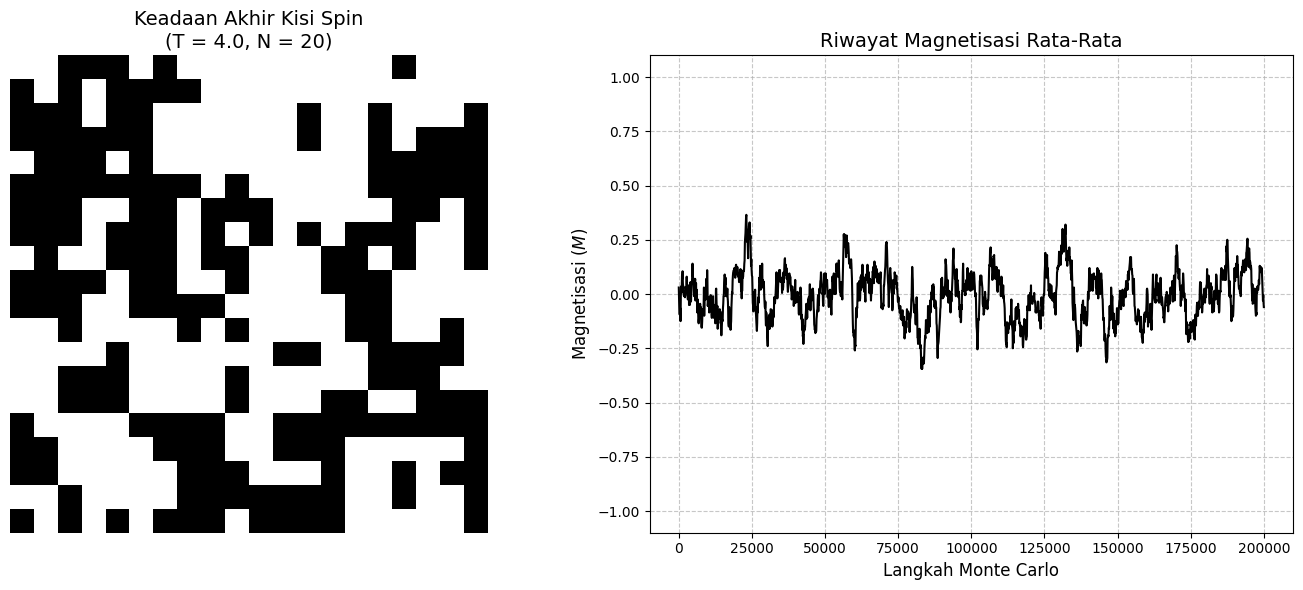

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Parameter Simulasi
# ==========================================
N = 20                 # Ukuran kisi N x N
T = 4.0                # Suhu tinggi (T > Tc)
MC_STEPS = 200000      # Total langkah Monte Carlo
RECORD_INTERVAL = 100  # Interval pengambilan sampel makrostate

# ==========================================
# Inisialisasi Sistem
# ==========================================
# Hot Start: Konfigurasi acak murni (entropi maksimum)
grid = np.random.choice([-1, 1], size=(N, N))

# Array penampung data
magnetization_history = []
time_steps = []

def calculate_magnetization(config):
    """Menghitung magnetisasi rata-rata sistem"""
    return np.sum(config) / (N * N)

# Catat keadaan awal
magnetization_history.append(calculate_magnetization(grid))
time_steps.append(0)

# Pra-kalkulasi probabilitas Boltzmann untuk optimasi komputasi
exp_dE = {dE: np.exp(-dE / T) for dE in [-8, -4, 0, 4, 8]}

# ==========================================
# Loop Algoritma Metropolis-Hastings
# ==========================================
for step in range(1, MC_STEPS + 1):
    # 1. Pilih koordinat spin secara acak
    i, j = np.random.randint(0, N, size=2)

    # 2. Syarat Batas Periodik (PBC)
    spin = grid[i, j]
    neighbors = (grid[(i + 1) % N, j] +
                 grid[(i - 1) % N, j] +
                 grid[i, (j + 1) % N] +
                 grid[i, (j - 1) % N])

    # 3. Perubahan energi (dE)
    dE = 2 * spin * neighbors

    # 4. Kriteria Metropolis
    # Probabilitas penerimaan spin-flip akan sangat tinggi karena suhu besar
    if dE <= 0 or np.random.rand() < exp_dE[dE]:
        grid[i, j] *= -1

    # 5. Sampling data makrostate
    if step % RECORD_INTERVAL == 0:
        magnetization_history.append(calculate_magnetization(grid))
        time_steps.append(step)

# ==========================================
# Visualisasi Data
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Keadaan Akhir Kisi
im = axes[0].imshow(grid, cmap='binary', vmin=-1, vmax=1)
axes[0].set_title(f'Keadaan Akhir Kisi Spin\n(T = {T}, N = {N})', fontsize=14)
axes[0].axis('off')

# Plot 2: Riwayat Magnetisasi
axes[1].plot(time_steps, magnetization_history, color='black', linewidth=1.5)
axes[1].set_title('Riwayat Magnetisasi Rata-Rata', fontsize=14)
axes[1].set_xlabel('Langkah Monte Carlo', fontsize=12)
axes[1].set_ylabel('Magnetisasi ($M$)', fontsize=12)
axes[1].set_ylim(-1.1, 1.1)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## **Hasil Analisis**

Pada suhu 𝑇 =
4.0
, sistem berada di atas suhu kritis (
𝑇
𝑐
≈
2.27
). Dalam kondisi ini, energi termal lebih dominan dibandingkan interaksi antar-spin sehingga arah spin berubah secara acak. Domain besar yang biasanya terbentuk pada suhu rendah tidak lagi muncul, dan magnetisasi rata-rata berfluktuasi di sekitar nol. Hal ini menandakan bahwa sistem telah memasuki fase paramagnetik, yaitu fase ketika material kehilangan magnetisasi spontan akibat pengaruh suhu tinggi.